#Project 3
#
For this project, I wanted to see if I could improve my results from Project 2. For a brief refresher, in Project 2, I took Georgia real estate from 2021. I used linear regression and I was able to get a R^2 score of 0.55. While that is a decent score, I felt that I could improve it.
#
So I am using the same data from Project 2 and I will use a gradient boosting model to see if I can get better accuracy this time around. In addition, I am going to try adding a few features back and see if that impacts the results at all.
#
Link to my github repository:

In [43]:
#The first step is to get everything set up and import the necessary modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv('/content/drive/MyDrive/RealEstate_Georgia.csv')


print(df.head())
print()
print("Shape of the DataFrame is:",df.shape)

print()
print(df.dtypes)


   Unnamed: 0                id  stateId  countyId  cityId country  \
0           0   31503-110785431       16        17   55064     USA   
1           1    31503-76611082       16        18   55064     USA   
2           2    31503-93126153       16        19   55064     USA   
3           3   31503-110785598       16        20   55064     USA   
4           4  31503-2101070583       16        21   55064     USA   

  datePostedString  is_bankOwned  is_forAuction            event  ...  \
0       2021-07-12             0              0  Listed for sale  ...   
1       2021-07-12             0              0  Listed for sale  ...   
2       2021-07-10             0              0  Listed for sale  ...   
3       2021-07-09             0              0  Listed for sale  ...   
4       2021-07-06             0              0  Listed for sale  ...   

   parking  garageSpaces  hasGarage levels pool  spa isNewConstruction  \
0        0           0.0          0      0    0    0              

Just like in Project 2, my problem statement remains the same.
My problem statement for this question is: How do property characteristics combine to determine home sale prices in Georgia, and which factors are most influential?

Throughout this project, my goal is to determine which characteristics impact home sale prices in Georgia the most. In doing so, I hope to provide specific characteristics that consumers can use to find the best possible home price.

The target variable for this project is:"price".

Describe the dataset: This data covers Georgia real estate data from the first six months of 2021. There are 39 columns and 13,804 homes listed. The variables contain things like "description", "yearBuilt", "homeType", etc. Next, I will go through the data and clean it as well as determining which columns are necessary.

In [44]:
#The first thing I will do is clean up the data.
#I will begin by dropping the columns I don't think I will need. I may add some back later if I find they will be useful.

# Drop irrelevant columns
columns_to_drop = [
    'Unnamed: 0','id','stateId','countyId','cityId','country',
    'datePostedString','time','event','currency','state',
    'streetAddress','hasBadGeocode','description','pricePerSquareFoot',
    'livingAreaValue','buildingArea','lotAreaUnits', 'longitude', 'latitude',
    'city', 'zipcode'
]
df_cleaned = df.drop(columns_to_drop, axis=1)

In [45]:
#The next thing I will do is drop any duplicate rows.

# Drop duplicate rows
df_cleaned = df_cleaned.drop_duplicates()
print(df_cleaned.shape)
print()
print("Shape of the DataFrame is:",df_cleaned.shape)

(11758, 17)

Shape of the DataFrame is: (11758, 17)


In [46]:
#I don't like the way the levels columns is split, there are too many confusing values.
#I am going to consolidate and standardize the names.

# Standardize 'levels' column
df_cleaned['levels'] = df_cleaned['levels'].replace({
    '0': 'Unknown','One': '1','Two': '2','Three Or More': '3+',
    'One and One Half': '1.5','2.5 Story': '2.5','3 Story': '3+',
    'Multi/Split': 'Split','Tri Level': 'Split','Tri-Level': 'Split',
    'Split Level': 'Split','Split Foyer': 'Split','2 Story or More': '2+',
    'Over 2 Stories': '2+','Two and One-Half': '2.5','One-One and One Half': '1.5',
    'One-Two': '1','Other-See Remarks': 'Other','Two-Multi/Split': 'Split',
    'Multi/Split-Split Level': 'Split','Two-Foyer - 2 Story': '2',
    'Three Or More-Two Story Foyer': '3+','One and One Half-Multi/Split': 'Split',
    'One and One Half-Two': '1.5','One-Manufactured Home 1 Story': '1',
    'Two-Three Or More': '2','Two-Split Foyer': 'Split','One-Mobile Home 1 Story': '1',
    'Manufactured Home 1 Story': '1','Split Foyer-Split Level': 'Split',
    'One and One Half-Split Level': 'Split','One-Two Story Foyer': '1',
    'Three Or More-Split Level-Tri-Level': 'Split','Split Level-Two': 'Split',
    'One-One and One Half-Two': '1.5','One-Other': 'Other','Two-Split Level': 'Split',
    'Tri Level-Split Level': 'Split','One-Two-Mobile Home 1 Story': '1',
    'Multi/Split-Two': 'Split'
})

In [47]:
# I noticed that a lot of the values in homeType are 'LOT'.
#I do not want empty Lots in my dataset, so I will drop them.

# Remove lots
df_cleaned = df_cleaned[df_cleaned['homeType'] != 'LOT']

In [48]:
#Now I am going to filter out unrealistic values from the data.

# Filter unrealistic values
df_filtered = df_cleaned[
    (df_cleaned['price'] > 0) &
    (df_cleaned['price'] < 2500000) &
    (df_cleaned['yearBuilt'] >= 1850) &
    (df_cleaned['yearBuilt'] <= 2021) &
    (df_cleaned['livingArea'] > 0) &
    (df_cleaned['livingArea'] < 9000) &
    (df_cleaned['bathrooms'] >= 0) &
    (df_cleaned['bathrooms'] <= 10) &
    (df_cleaned['bedrooms'] >= 0) &
    (df_cleaned['bedrooms'] <= 10) &
    (df_cleaned['garageSpaces'] <= 5)
]

In [49]:
#Now I am going to filter out unrealistic values from the data.

# Remove outliers using IQR for price
Q1_price = df_filtered['price'].quantile(0.25)
Q3_price = df_filtered['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
df_filtered = df_filtered[
    (df_filtered['price'] >= Q1_price - 1.5*IQR_price) &
    (df_filtered['price'] <= Q3_price + 1.5*IQR_price)
]

# Remove outliers using IQR for livingArea
Q1_area = df_filtered['livingArea'].quantile(0.25)
Q3_area = df_filtered['livingArea'].quantile(0.75)
IQR_area = Q3_area - Q1_area
df_filtered = df_filtered[
    (df_filtered['livingArea'] >= Q1_area - 1.5*IQR_area) &
    (df_filtered['livingArea'] <= Q3_area + 1.5*IQR_area)
]


In [50]:
#There are so many counties that I will filter them down to the top 15 plus Other.
# Simplify county to top 15 + Other
top_counties = df_filtered['county'].value_counts().head(15).index
df_filtered['county'] = df_filtered['county'].where(
    df_filtered['county'].isin(top_counties), 'Other'
)


In [51]:
# Select only numeric columns for correlation
numeric_df = df_filtered.select_dtypes(include=[np.number])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Print correlations with price
print(corr_matrix['price'].sort_values(ascending=False))

price                1.000000
livingArea           0.628618
bathrooms            0.608329
hasGarage            0.407556
garageSpaces         0.390726
bedrooms             0.367729
yearBuilt            0.317525
parking              0.287097
spa                  0.226183
isNewConstruction    0.111174
pool                 0.106124
is_bankOwned        -0.011072
hasPetsAllowed      -0.012895
is_forAuction       -0.017011
Name: price, dtype: float64


In [52]:
#Now I am going to eliminate some more features that are not as relevant.

# Drop insignificant features
df_model_clean = df_filtered.drop(columns=['levels', 'is_forAuction', 'is_bankOwned', 'hasPetsAllowed'])


In [53]:
#Next I will do hot encoding for the categorical features.

# One-hot encoding for categorical variables
df_model_clean = pd.get_dummies(df_model_clean, columns=['homeType', 'county'], drop_first=True)

In [54]:
#In an effort to improve my model's performance, I am going to add back zipcode, longitude, and latitude.

# Add latitude and longitude
df_model_clean['latitude'] = df['latitude']
df_model_clean['longitude'] = df['longitude']


if df['zipcode'].nunique() < 150:
    zipcode_dummies = pd.get_dummies(df['zipcode'], prefix='zip', drop_first=True)
    df_model_clean = pd.concat([df_model_clean, zipcode_dummies], axis=1)

In [55]:
# Fill any remaining missing values
df_model_clean = df_model_clean.fillna(df_model_clean.median())

In [56]:
#Now I am going to split the data into training and testing sets.

X = df_model_clean.drop('price', axis=1)
y = df_model_clean['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [57]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_samples_split=10,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred = gb_model.predict(X_test)

Gradient Boosting Results:
R² Score: 0.7184
RMSE: $93,093.14
MAE: $63,188.60


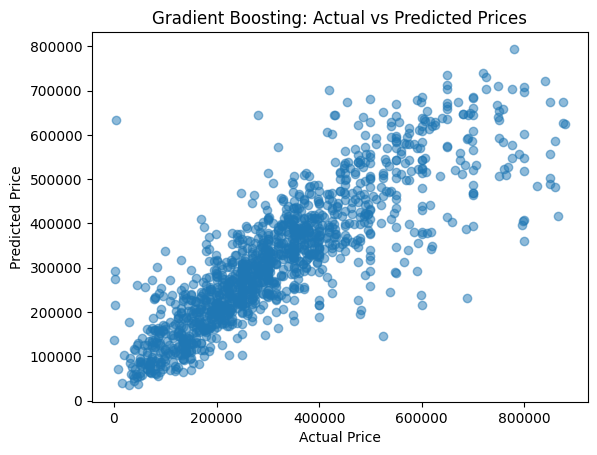

In [58]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Gradient Boosting Results:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE: ${mae:,.2f}")


plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient Boosting: Actual vs Predicted Prices")
plt.show()

In [59]:
#Saving the model to pickle
import pickle
pickle.dump(gb_model, open("model.pkl", "wb"))
feature_columns = X_train.columns.tolist()
pickle.dump(feature_columns, open("feature_columns.pkl", "wb"))

print("Model and feature columns saved successfully!")
print(f"Number of features: {len(feature_columns)}")

Model and feature columns saved successfully!
Number of features: 30


In [60]:
# Load the model and feature columns
model = pickle.load(open('model.pkl', 'rb'))
feature_columns = pickle.load(open('feature_columns.pkl', 'rb'))

print(f"Model loaded with {len(feature_columns)} features")


# Create test input as a dictionary
input_data = {
    'yearBuilt': 2018,
    'livingArea': 2000,
    'bathrooms': 2.5,
    'bedrooms': 3,
    'parking': 1,
    'garageSpaces': 2,
    'hasGarage': 1,
    'pool': 0,
    'spa': 0,
    'isNewConstruction': 0,
    'latitude': 33.7490,
    'longitude': -84.3880,
    'homeType_SINGLE_FAMILY': 1,
    'homeType_MULTI_FAMILY': 0,
    'homeType_TOWNHOUSE': 0,
    'county_Fulton County': 1,
    'county_Chatham County': 0,
    'county_Cherokee County': 0,
    'county_Clayton County': 0,
    'county_Cobb County': 0,
    'county_Dekalb County': 0,
    'county_Dougherty County': 0,
    'county_Gwinnett County': 0,
    'county_Hall County': 0,
    'county_Henry County': 0,
    'county_Houston County': 0,
    'county_Muscogee County': 0,
    'county_Other': 0,
    'county_Paulding County': 0,
    'county_Richmond County': 0
}

# Convert to DataFrame with correct feature order
input_df = pd.DataFrame([input_data], columns=feature_columns)

# Make prediction
result = model.predict(input_df)
print(f"\nPredicted Price: ${result[0]:,.2f}")

Model loaded with 30 features

Predicted Price: $599,270.00
